In [8]:
import pandas as pd

file_path = "/Titanic-Dataset.csv"
data = pd.read_csv(file_path)

# Display the first few rows to confirm it's loaded correctly
display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Importação de bibliotecas**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns
#from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

#from sklearn.feature_selection import SelectKBest, f_classif
#from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

# Importação do rpy2 para poder utilizar a função rpart do R
# (que contém uma implementação mais fiel do CART original)
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr


# Suprimir warnings do rpy2
import logging
rpy2_logger = logging.getLogger('rpy2')
rpy2_logger.setLevel(logging.ERROR)

# Também suprimir warnings do R
import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore", category=RRuntimeWarning)

# Suprimir warnings genéricos
warnings.filterwarnings("ignore")



**Carregar os pacotes do R**

In [10]:
# Ativar conversão automática pandas <-> R
pandas2ri.activate()

# Carregar pacotes do R
rpart = importr('rpart')
grdevices = importr('grDevices')

# Instalar e importar o rpart.plot
utils = importr('utils')
utils.install_packages('rpart.plot')
rpart_plot = importr('rpart.plot')

base = importr('base')
graphics = importr('graphics')
stats = importr('stats')

**Carga dos dados**

In [11]:
# Altere o diretório de acordo com seu ambiente
file = "/Titanic-Dataset.csv"
data = pd.read_csv(file)

# Converter a variável resposta para fatores com labels
data['Survived'] = data['Survived'].map({0: 'N', 1: 'Y'})

data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,N,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Y,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Y,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Y,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,N,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Variáveis**

PassengerId: Número sequencial

Survived: Variável resposta. 0 = No, 1 = Yes

Pclass: Classe do ticket. 1=1a, 2=2a, 3=3a

Sex: male / female

Age: Idade em anos

SibSp: Número de irmãos/cônjuges a bordo

Parch: Número de pais/filhos a bordo

Ticket: Número do bilhete

Fare: Tarifa da passagem

Embarked: Porto de embarque:
C=Cherbourg, Q=Queenstown, S=Southampton


**Sumário geral dos dados**

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


**Dados faltantes por variável**

In [13]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Limpeza dos dados**

Nome, Id do passageiro e número do bilhete não parecem ter efeito com a chance de sobrevivência, e portanto serão eliminados

In [14]:
# Name, PassengerId e ticket number não parecem ter efeito com a chance de sobrevivência, e portanto serão eliminadas
data = data.drop('PassengerId', axis=1)
data = data.drop('Name', axis=1)
data = data.drop('Ticket', axis=1)
data = data.drop('Cabin', axis=1)

**Engenharia de atributos**

Criação da variável FamilySize

In [15]:
data['FamilySize'] = 1+data['SibSp']+data['Parch']

**Conversão de variáveis categóricas para fatores do R**

In [16]:
# Converter variáveis categóricas para fatores do R
data['Sex'] = data['Sex'].astype('category')
data['Pclass'] = data['Pclass'].astype('category') # Corrected from 'PassClass' to 'Pclass'
data['Embarked'] = data['Embarked'].astype('category')
data['Survived'] = data['Survived'].astype('category')

In [ ]:
#mapping = {'female' : 0, 'male' : 1}
#data['Sex'] = data['Sex'].map(mapping)

In [ ]:
#data = pd.get_dummies(data, columns=['Embarked'], drop_first=True, dtype=int)

In [17]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,N,3,male,22.0,1,0,7.2500,S,2
1,Y,1,female,38.0,1,0,71.2833,C,2
2,Y,3,female,26.0,0,0,7.9250,S,1
3,Y,1,female,35.0,1,0,53.1000,S,2
4,N,3,male,35.0,0,0,8.0500,S,1


**EDA**

In [18]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'FamilySize'],
      dtype='object')

Survived    N    Y
Sex               
female     81  233
male      468  109


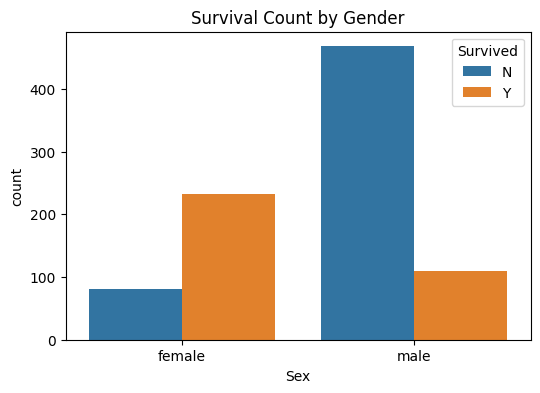

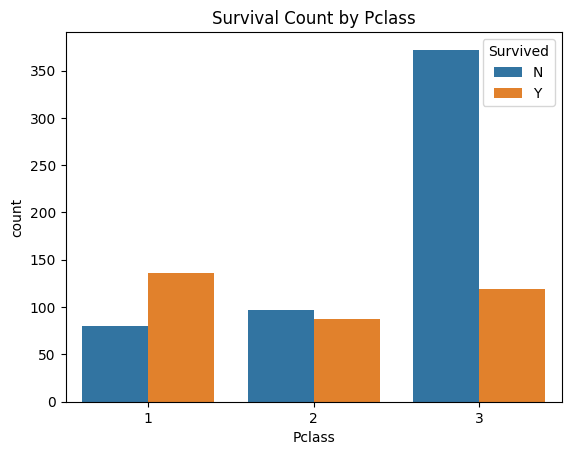

In [19]:
table = sm.stats.Table.from_data(data[["Sex", "Survived"]])
print(table.table_orig)

# plt.figure(figsize=(6,4))
# sns.barplot(x='Sex', y='Survived', data=data, ci=None)
# plt.title('Survival rate by sex (mean survived)')
# plt.show()

# plt.figure(figsize=(8,4))
# sns.barplot(x='Pclass', y='Survived', data=data, ci=None)
# plt.title('Survival by class')
# plt.show()

# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=data)
plt.title("Survival Count by Gender")
plt.show()

# Survival by Passenger Class
sns.countplot(x="Pclass", hue="Survived", data=data)
plt.title("Survival Count by Pclass")
plt.show()



Survival rates are much higher for women than men, making Gender one of the most important features.  

In tree-based models, Gender (Sex) can be a very strong splitting feature at the root or near the root of the decision tree.

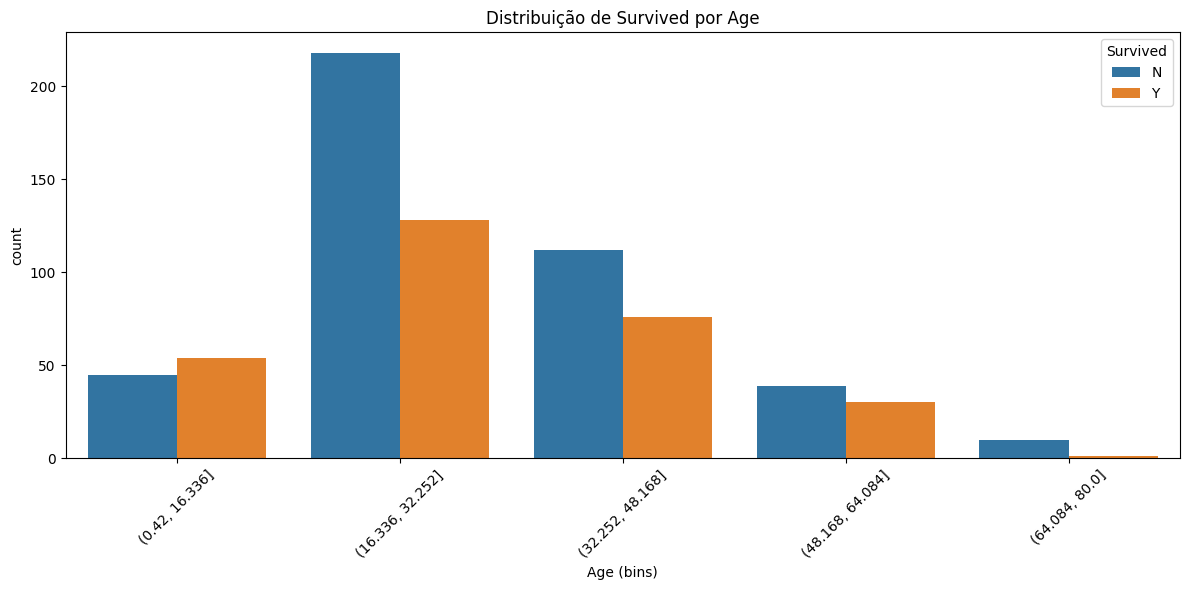

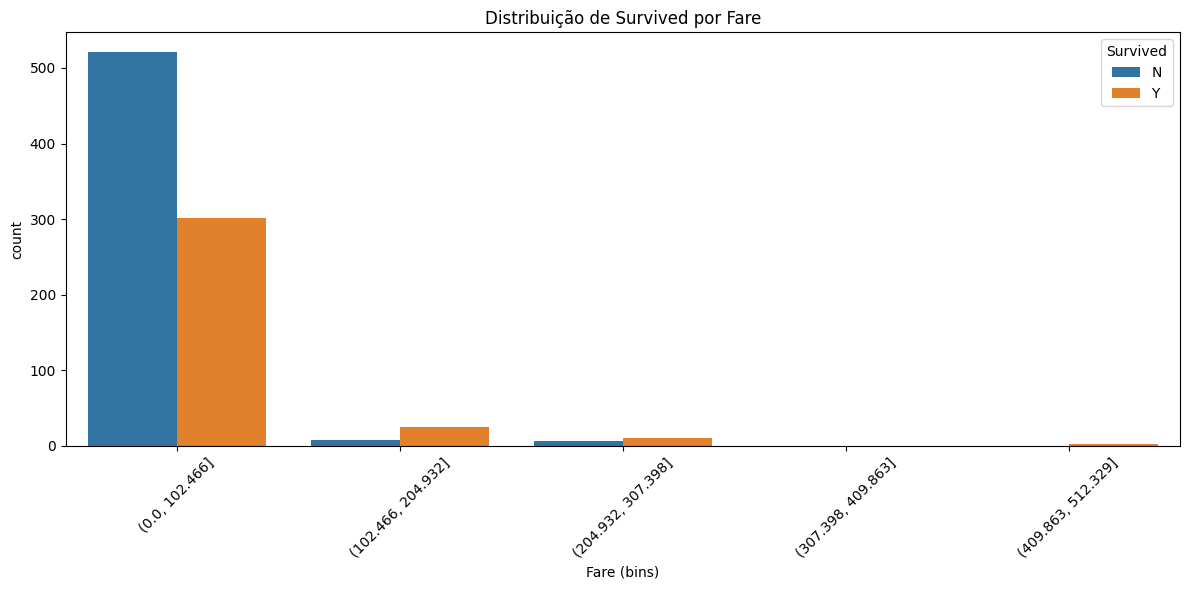

In [20]:
# Histograma estratificado
def plot_stratified_histogram(data, numeric_var, target_var, n_bins=10):
    """
    Plota histograma estratificado por uma variável numérica e target

    Parameters:
    data: DataFrame
    numeric_var: nome da variável numérica (ex: 'Age')
    target_var: nome da variável target (ex: 'Survived')
    n_bins: número de bins
    """
    # Criar bins automaticamente
    min_val = data[numeric_var].min()
    max_val = data[numeric_var].max()
    bins = np.linspace(min_val, max_val, n_bins + 1)

    # Adicionar coluna temporária com bins
    data['temp_bin'] = pd.cut(data[numeric_var], bins=bins)

    # Criar plot
    plt.figure(figsize=(12, 6))
    sns.countplot(x='temp_bin', hue=target_var, data=data)
    plt.title(f'Distribuição de {target_var} por {numeric_var}')
    plt.xticks(rotation=45)
    plt.xlabel(f'{numeric_var} (bins)')
    plt.legend(title=target_var)
    plt.tight_layout()
    plt.show()

    # Remover coluna temporária
    data.drop('temp_bin', axis=1, inplace=True)

# Histograma por idade:
plot_stratified_histogram(data, 'Age', 'Survived', n_bins=5)

# Histograma por tarifa:
plot_stratified_histogram(data, 'Fare', 'Survived', n_bins=5)

Notamos acima que a variável Fare é bastante assimétrica.
Aplicaremos o logaritmo nesta variável para obtermos uma visualização melhor.

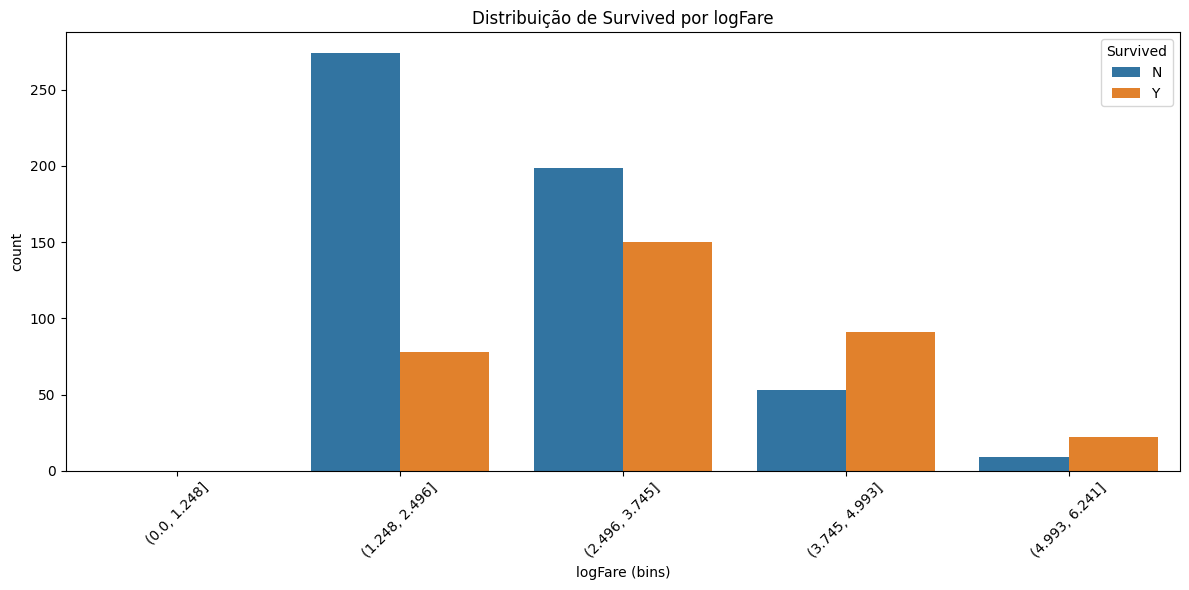

In [21]:
data['logFare'] = np.log(data['Fare']+1)
plot_stratified_histogram(data, 'logFare', 'Survived', n_bins=5)

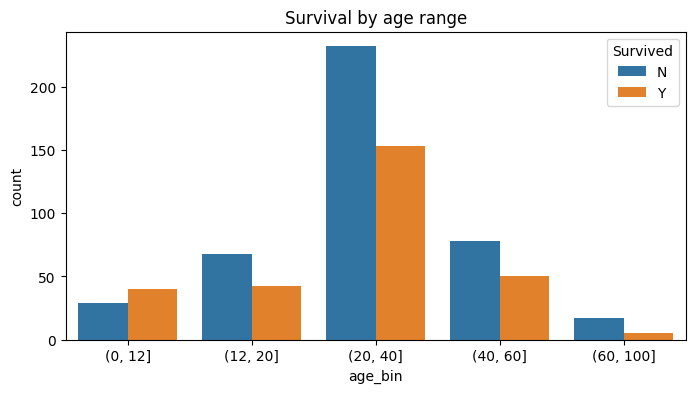

In [22]:
# Create a temporary column 'age_bin'
data['age_bin'] = pd.cut(data['Age'], bins=[0,12,20,40,60,100])

# sns.barplot(x='age_bin', y='Survived', data=data, ci=None)
# plt.xticks(rotation=45)
# plt.title('Survival by age range')
# plt.show()

# Survival by Gender
plt.figure(figsize=(8,4))
sns.countplot(x="age_bin", hue="Survived", data=data)
plt.title("Survival by age range")
plt.show()

# Remove temporary column 'age_bin'
data.drop("age_bin", axis=1, inplace=True)

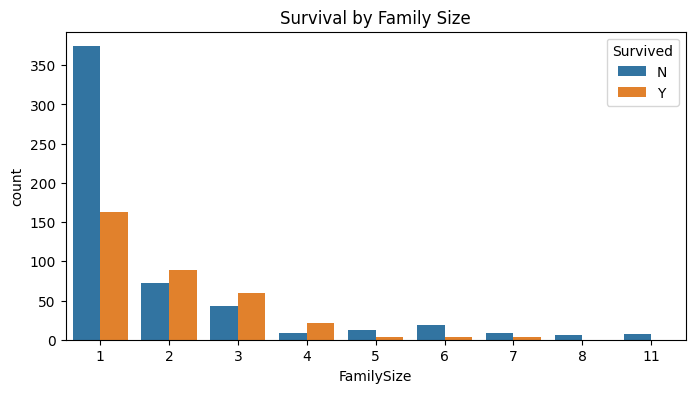

In [23]:
# sns.barplot(x='FamilySize', y='Survived', data=data, ci=None)
# plt.title('Survival by family size')
# plt.show()

# Survival by Gender
plt.figure(figsize=(8,4))
sns.countplot(x="FamilySize", hue="Survived", data=data)
plt.title("Survival by Family Size")
plt.show()

**Aplicação do algoritmo de indução de árvore de classificação**

In [28]:
# Divisão em treino (70%) e teste (30%)
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

print(f"Treino: {len(train_data)} amostras")
print(f"Teste: {len(test_data)} amostras")

# Conversão dos DataFrames pandas para R
with ro.conversion.localconverter(ro.default_converter + pandas2ri.converter):
    train_r = ro.conversion.py2rpy(train_data)
    test_r = ro.conversion.py2rpy(test_data)

# Parametros de controle de complexidade das árvores no rpart
minsplit=0
minbucket=0
cp=0.00

# Construir a árvore de classificação (Função rpart do R)
formula = ro.Formula('Survived ~ .')
rpart_model = rpart.rpart(
    formula=formula,
    data=train_r,
    method="class",
    minsplit=minsplit,
    minbucket=minbucket,
    cp=cp
)

# Gerar previsões
train_predictions_r = stats.predict(rpart_model, newdata=train_r, type="class")
test_predictions_r = stats.predict(rpart_model, newdata=test_r, type="class")

# Obter os resultados como character vector
# (para evitar uma conversão inadequada para números)
train_predictions_chr = ro.r['as.character'](train_predictions_r)
test_predictions_chr = ro.r['as.character'](test_predictions_r)

# Por fim, converter as previsões em arrays no Python
train_pred = np.array(train_predictions_chr)
test_pred = np.array(test_predictions_chr)

# Valores reais
y_train = train_data['Survived'].values
y_test = test_data['Survived'].values


#print("Valores únicos no y_train:", np.unique(y_train))
#print("Valores únicos nas previsões de treino:", np.unique(train_pred))
#print("Valores únicos no y_test:", np.unique(y_test))
#print("Valores únicos nas previsões de teste:", np.unique(test_pred))

# Matriz de confusão - Treino
cm_train = confusion_matrix(y_train, train_pred)
print("=== MATRIZ DE CONFUSÃO - TREINO ===")
print(cm_train)
print("\nRelatório de classificação - Treino:")
print(classification_report(y_train, train_pred))

# Matriz de confusão - Teste
cm_test = confusion_matrix(y_test, test_pred)
print("\n=== MATRIZ DE CONFUSÃO - TESTE ===")
print(cm_test)
print("\nRelatório de classificação - Teste:")
print(classification_report(y_test, test_pred))




Treino: 623 amostras
Teste: 268 amostras
=== MATRIZ DE CONFUSÃO - TREINO ===
[[387   5]
 [ 10 221]]

Relatório de classificação - Treino:
              precision    recall  f1-score   support

           N       0.97      0.99      0.98       392
           Y       0.98      0.96      0.97       231

    accuracy                           0.98       623
   macro avg       0.98      0.97      0.97       623
weighted avg       0.98      0.98      0.98       623


=== MATRIZ DE CONFUSÃO - TESTE ===
[[130  27]
 [ 31  80]]

Relatório de classificação - Teste:
              precision    recall  f1-score   support

           N       0.81      0.83      0.82       157
           Y       0.75      0.72      0.73       111

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.78      0.78      0.78       268



**Avaliação do modelo**

In [29]:
# 5. Calcular métricas
def calculate_metrics(y_true, y_pred, set_name):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    # Verificar se é binário ou multiclasse
    n_classes = len(np.unique(y_true))

    sensitivity = recall_score(y_true, y_pred, pos_label=1, average='macro')
    specificity = recall_score(y_true, y_pred, pos_label=0, average='macro')

    print(f"\n--- Métricas Binárias {set_name} ---")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Sensibilidade: {sensitivity:.4f}")
    print(f"Especificidade: {specificity:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    return accuracy, sensitivity, specificity, macro_f1

# Calcular para treino e teste
accuracy, sensitivity, specificity, macro_f1 = calculate_metrics(y_train, train_pred, "Treino")

print()

calculate_metrics(y_test, test_pred, "Teste")

# Opcional: imprimir resumo do modelo
print("\n--- Resumo do modelo: ---")
print(rpart_model)


--- Métricas Binárias Treino ---
Acurácia: 0.9759
Sensibilidade: 0.9720
Especificidade: 0.9720
Macro-F1: 0.9741


--- Métricas Binárias Teste ---
Acurácia: 0.7836
Sensibilidade: 0.7744
Especificidade: 0.7744
Macro-F1: 0.7758

--- Resumo do modelo: ---
n= 623 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

     1) root 623 231 N (0.62921348 0.37078652)  
       2) Sex=male 410  76 N (0.81463415 0.18536585)  
         4) Age>=6.5 390  62 N (0.84102564 0.15897436)  
           8) Fare< 52.2771 344  45 N (0.86918605 0.13081395)  
            16) Age< 77 343  44 N (0.87172012 0.12827988)  
              32) Pclass=2,3 300  34 N (0.88666667 0.11333333)  
                64) Age>=32.25 85   5 N (0.94117647 0.05882353)  
                 128) Fare< 7.9104 30   0 N (1.00000000 0.00000000) *
                 129) Fare>=7.9104 55   5 N (0.90909091 0.09090909)  
                   258) Fare>=7.9875 51   3 N (0.94117647 0.05882353)  
                     516) Age< 61 49   2 N

**Exibição da árvore**

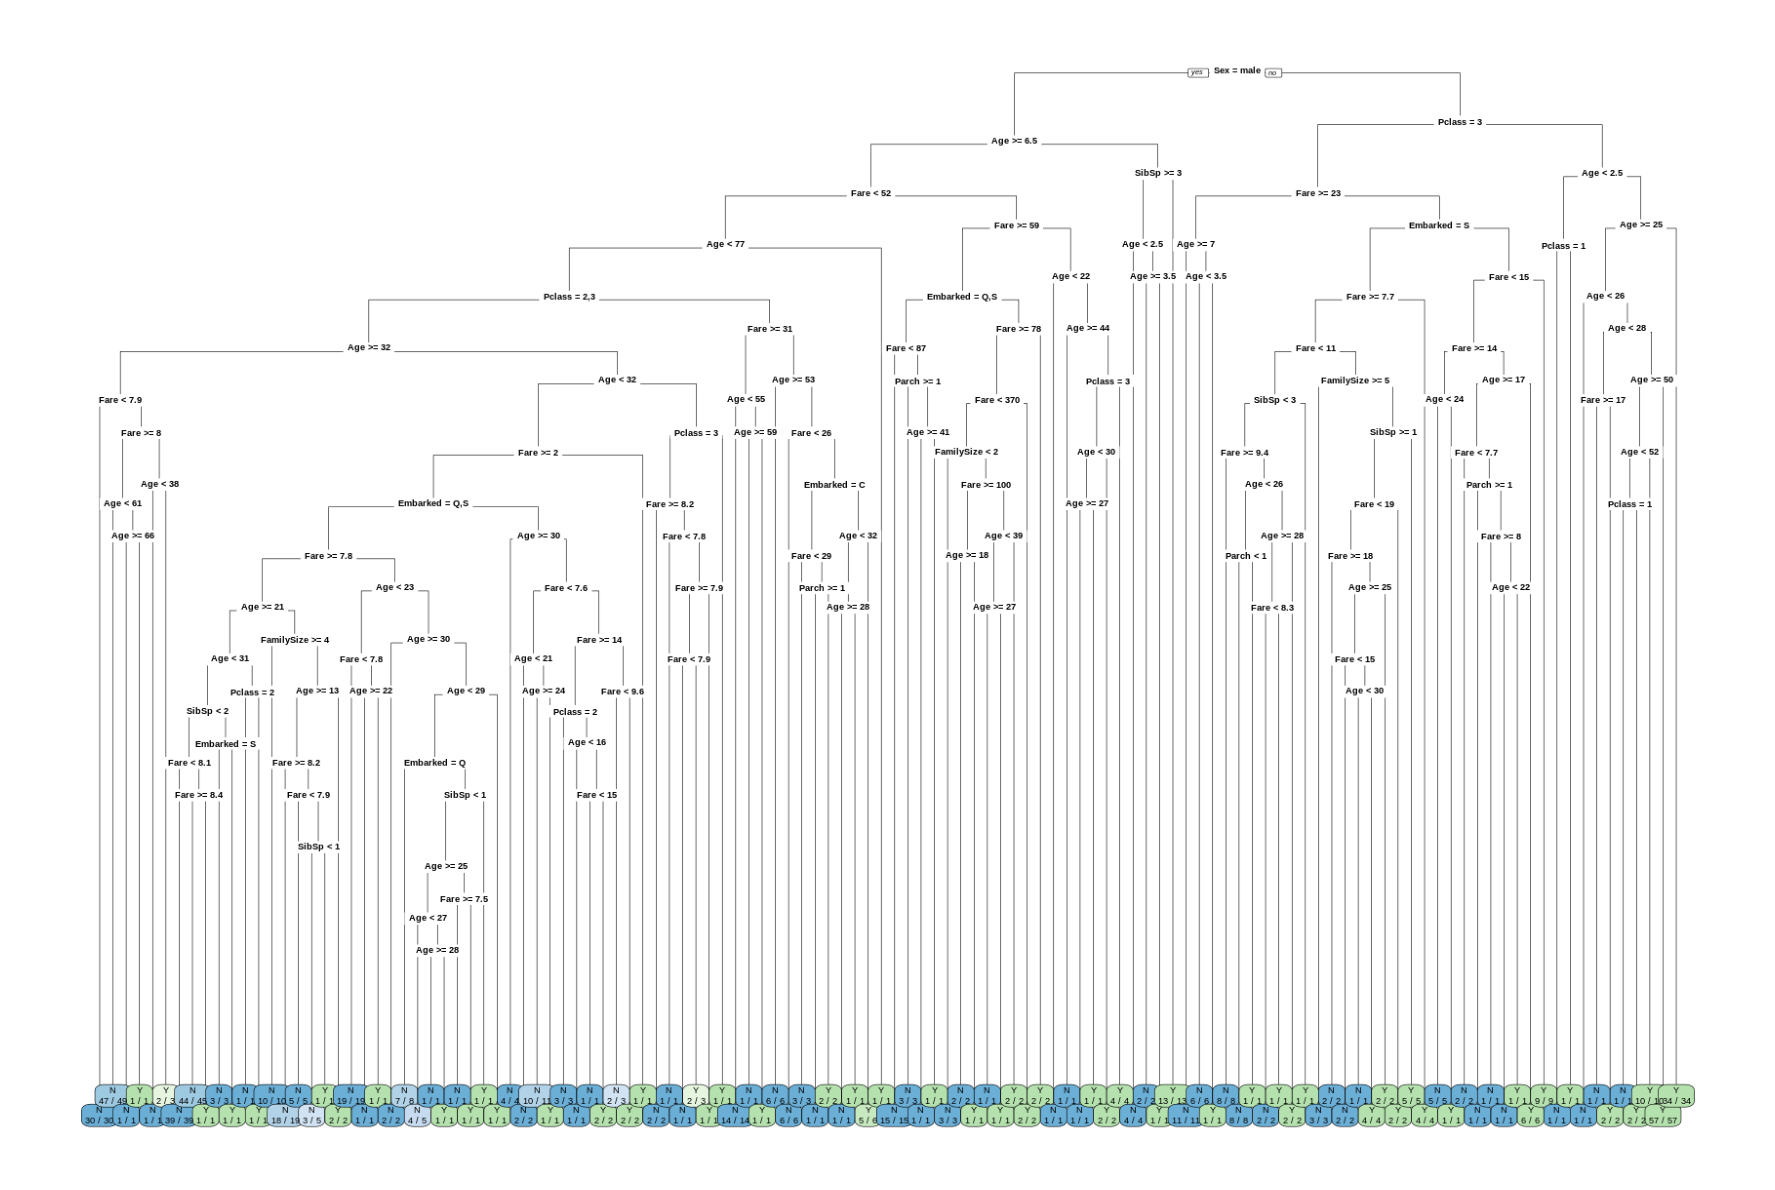

In [30]:
#import rpy2.robjects.lib.grdevices as grdevices
#import rpy2.robjects.lib.rpart_plot as rpart_plot

grdevices.png(filename="arvore_rpart.png", width=1800, height=1200)  # Bem grande
rpart_plot.rpart_plot(rpart_model, type=0, extra=2, tweak=1.5)
grdevices.dev_off()

# Mostrar ocupando mais espaço
img = mpimg.imread('arvore_rpart.png')
plt.figure(figsize=(20, 12))  # Figura maior no matplotlib
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

**Avaliação da importância das variáveis:**

     variable  importance
0        Fare   97.759579
1     logFare   86.388779
2         Sex   82.459093
3         Age   60.846113
4      Pclass   34.933591
5  FamilySize   32.799234
6       SibSp   24.941185
7    Embarked   20.023973
8       Parch   18.980176


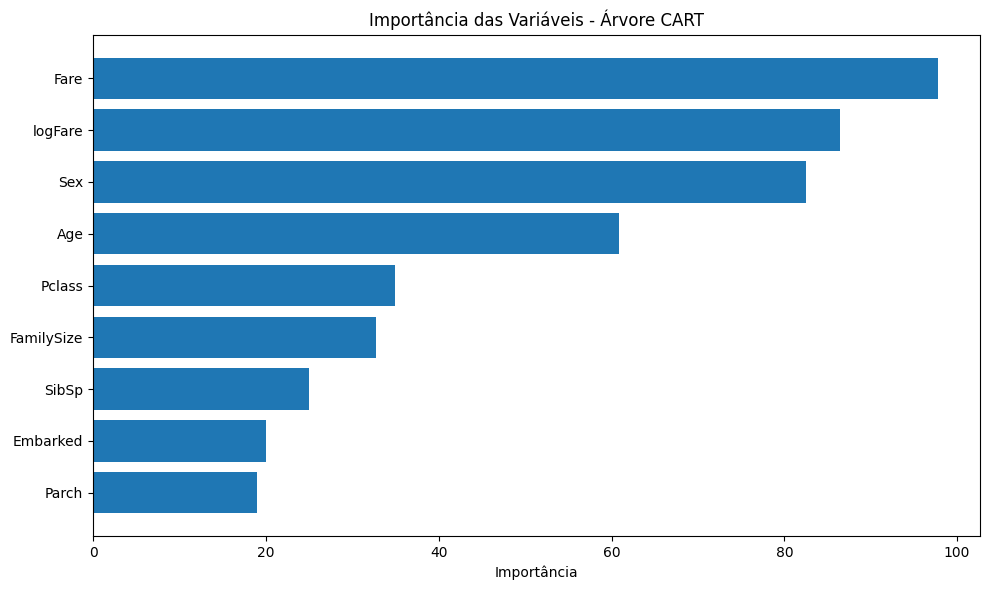

In [31]:
# Usar R para criar um data.frame com nomes e importâncias
ro.r('''
var_imp_df <- function(model) {
  imp <- model$variable.importance
  if(is.null(imp)) return(NULL)
  data.frame(
    variable = names(imp),
    importance = as.numeric(imp)
  )
}
''')

var_imp_df = ro.r['var_imp_df'](rpart_model)

if var_imp_df is not None:
    # Converter para pandas
    var_imp_py = pd.DataFrame({
        'variable': np.array(var_imp_df.rx2('variable')),
        'importance': np.array(var_imp_df.rx2('importance'))
    })

    print(var_imp_py.sort_values('importance', ascending=False))

    # Ordenar por importância
    var_imp_sorted = var_imp_py.sort_values('importance', ascending=True)

    # Plotar
    plt.figure(figsize=(10, 6))
    plt.barh(var_imp_sorted['variable'], var_imp_sorted['importance'])
    plt.xlabel('Importância')
    plt.title('Importância das Variáveis - Árvore CART')
    plt.tight_layout()
    plt.show()

else:
    print("Não há importância de variáveis disponível")




**Créditos:**

Análise exploratória adaptada de:
https://www.kaggle.com/code/seifeldin7/titanic-dt-rf-pipeline-with-full-tuning

# Análise de Sensibilidade do Parâmetro cp

In [33]:
cp_values = np.arange(0.000, 0.102, 0.002)  # De 0.000 a 0.100 com passo 0.002
results = []

for cp in cp_values:
    # Construir a árvore com o cp corrente (minsplit=0, minbucket=0)
    rpart_model = rpart.rpart(
        formula=formula,
        data=train_r,
        method="class",
        minsplit=0,
        minbucket=0,
        cp=cp
    )

    # Previsões para treino e teste
    train_predictions_r = stats.predict(rpart_model, newdata=train_r, type="class")
    test_predictions_r = stats.predict(rpart_model, newdata=test_r, type="class")

    # Conversão para arrays Python
    train_pred = np.array(ro.r['as.character'](train_predictions_r))
    test_pred = np.array(ro.r['as.character'](test_predictions_r))

    # Calcular acurácia
    acc_train = accuracy_score(y_train, train_pred)
    acc_test = accuracy_score(y_test, test_pred)

    # Armazenar resultados
    results.append([cp, acc_train, acc_test])

# Criar DataFrame final com resultados
df_cp = pd.DataFrame(results, columns=["CP", "Acc_Train", "Acc_Test"])

print(" Resultados de Acurácia por CP ")
display(df_cp.head())
print(f"Total de linhas: {len(df_cp)} (deverá ter 51)")



 Resultados de Acurácia por CP 


,CP,Acc_Train,Acc_Test
0,0.000,0.975923,0.783582
1,0.002,0.943820,0.802239
2,0.004,0.897271,0.805970
3,0.006,0.873194,0.798507
4,0.008,0.873194,0.798507


Total de linhas: 51 (deverá ter 51)


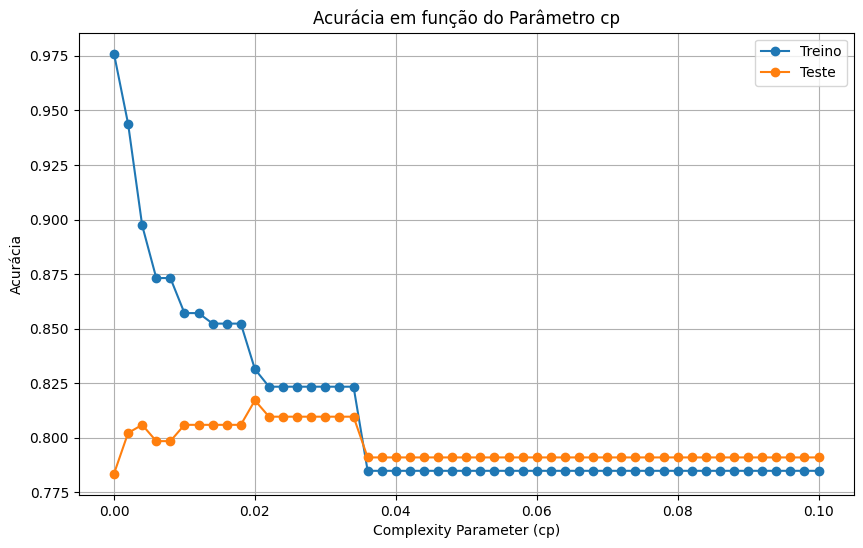

In [34]:
# Gráfico de Acurácia x CP
plt.figure(figsize=(10, 6))
plt.plot(df_cp["CP"], df_cp["Acc_Train"], label="Treino", marker="o")
plt.plot(df_cp["CP"], df_cp["Acc_Test"], label="Teste", marker="o")
plt.xlabel("Complexity Parameter (cp)")
plt.ylabel("Acurácia")
plt.title("Acurácia em função do Parâmetro cp")
plt.legend()
plt.grid(True)
plt.show()